In [4]:
pip install pandas

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics


In [6]:
gold_data=pd.read_csv('/content/gld_price_data.csv')

In [7]:
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [8]:
gold_data.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [9]:
gold_data.shape

(2290, 6)

In [10]:
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [11]:
gold_data.isnull().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


In [12]:
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


In [13]:
correlation=gold_data.drop('Date',axis=1).corr()

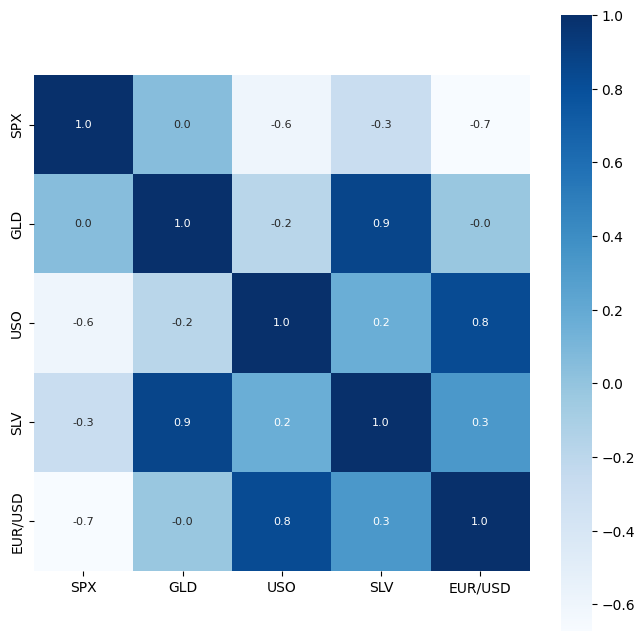

In [14]:
plt.figure(figsize=(8,8));
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues'); plt.show()



In [15]:
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


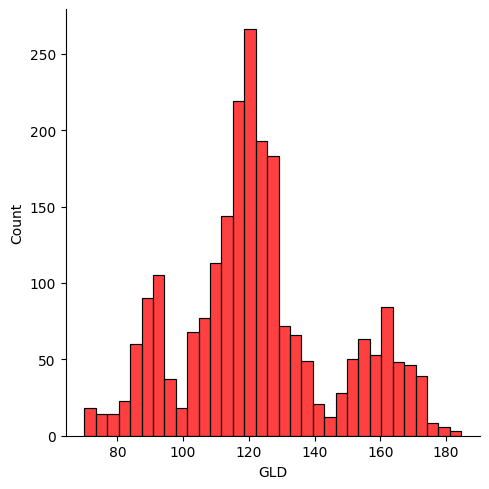

In [16]:
sns.displot(gold_data['GLD'],color='red')

In [17]:
X=gold_data.drop(['Date','GLD',],axis=1)
Y=gold_data['GLD']

In [18]:
print(X)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]


In [ ]:
print(Y)

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


In [19]:
X_train,X_test,Y_train,Y_test= train_test_split(X,Y,test_size=0.2,random_state=2)

In [20]:
regressor=RandomForestRegressor(n_estimators=100)

In [21]:
regressor.fit(X_train, Y_train)

RandomForestRegressor()

In [22]:
test_data_prediction=regressor.predict(X_test)

In [23]:
print(test_data_prediction)

[168.67889954  82.02469977 116.26370032 127.60100114 120.78150125
 154.64429747 150.06569882 126.24110018 117.45539875 125.94660061
 116.71370108 172.02120131 141.28039877 167.90069852 115.22089997
 118.12100066 138.48860313 170.48370123 159.2991026  158.29639913
 155.1368006  125.33450012 175.32469996 157.49080263 125.2361003
  93.81819988  77.05229979 120.38490023 119.02419884 167.39459987
  88.24800036 125.26849984  91.25880069 117.5832004  121.167399
 136.45130007 115.63830129 115.17470081 147.2101996  107.17180115
 104.28070263  87.10099793 126.43680058 118.09099968 153.45539885
 119.47100025 108.37740027 108.16849851  93.12270051 127.07029812
  74.8144002  113.62899908 121.30809996 111.37129892 118.72609896
 120.7371992  159.13810023 167.199801   147.00379668  86.20479901
  94.10310043  86.89249883  90.69660002 119.05300088 126.47260049
 127.48620018 170.43290001 122.37379942 117.36059888  98.37660022
 168.32240069 142.9596975  132.19230296 121.20570192 120.58879952
 119.65240052

In [24]:
error_score=metrics.r2_score(Y_test,test_data_prediction)
print("R squared error:",error_score)

R squared error: 0.9889900522953382


In [25]:
Y_test=list(Y_test)

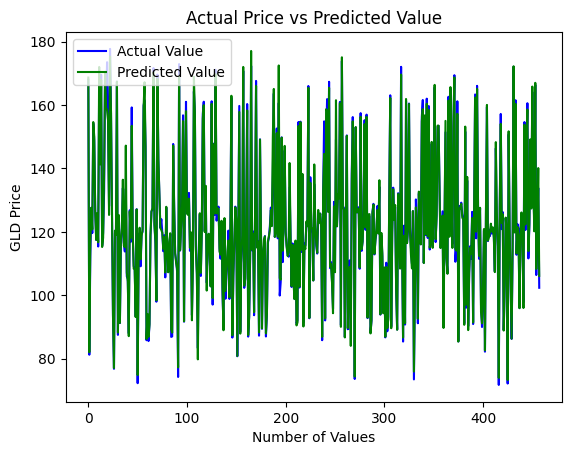

In [26]:
plt.plot(Y_test, color='blue', label='Actual Value')
plt.plot(test_data_prediction, color='green', label='Predicted Value')
plt.title('Actual Price vs Predicted Value')
plt.xlabel('Number of Values')
plt.ylabel('GLD Price')
plt.legend(loc='upper left')
plt.show()

